In [2]:
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error as ms

In [3]:
ens = xr.open_dataset('/media/athira/One Touch/final_datasets/Edited_plots/merged_files/pH_ensemble_ssp126_merged_r1.nc')

bc_ens = xr.open_dataset('/media/athira/One Touch/final_datasets/Edited_plots/merged_files/ph_ens_ssp585_biascorrected_mean.nc')

tak = xr.open_dataset('/media/athira/One Touch/final_datasets/Takahashi_clim_mask.nc')

# ds3 = xr.open_dataset('JMA_MLRmasked.nc')

lat_range = slice(-30, 30)
lon_range = slice(30, 120)

ds1= xr.open_dataset('/media/athira/One Touch/final_datasets/ph_data_masked/ph_canesm_hist_mask.nc')
ds2= xr.open_dataset('/media/athira/One Touch/final_datasets/ph_data_masked/ph_cesm2_hist_mask.nc')

ds3= xr.open_dataset('/media/athira/One Touch/pH_CMIP6/Replots_pH/CESM2/ph_CESM2_historical_mask.nc')
ds4= xr.open_dataset('/media/athira/One Touch/pH_CMIP6/Replots_pH/CMCC/ph_CMCC_historical_mask.nc')
ds5= xr.open_dataset('/media/athira/One Touch/final_datasets/ph_data_masked/ph_gfdl-esm4_hist_mask.nc')
ds6= xr.open_dataset('/media/athira/One Touch/pH_CMIP6/Replots_pH/IPSL/ph_IPSL_historical_mask.nc')
ds7= xr.open_dataset('/media/athira/One Touch/final_datasets/ph_data_masked/ph_mpi-esm-hr_hist_mask.nc')
ds8= xr.open_dataset('/media/athira/One Touch/final_datasets/ph_data_masked/ph_noresm-mm_hist_mask.nc')
ds9= xr.open_dataset('/media/athira/One Touch/final_datasets/ph_data_masked/ph_noresm-lm_hist_mask.nc')

cmems = xr.open_dataset('/media/athira/One Touch/pH_CMIP6/CMEMS/cmems_new/CMEMS_ph_mask.nc')
soda = xr.open_dataset('/media/athira/One Touch/pH_CMIP6/SODA/SODA_new/SODA_ph_mask.nc')
obs= xr.open_dataset('JMA_MLR_pH_only.nc')






In [4]:
ens

<xarray.Dataset> Size: 62MB
Dimensions:   (time: 1392, lat: 61, lon: 91)
Coordinates:
  * time      (time) object 11kB 1985-01-15 12:00:00 ... 2100-12-15 12:00:00
    lev       float64 8B ...
    DEPTH1_1  float32 4B ...
    TIME      datetime64[ns] 8B ...
  * lat       (lat) float32 244B -29.88 -29.38 -28.38 ... 27.62 28.62 29.62
  * lon       (lon) float32 364B 30.12 31.12 32.12 33.12 ... 118.1 119.1 119.9
    olevel    float32 4B ...
Data variables:
    ph        (time, lat, lon) float64 62MB ...

In [5]:

obs = obs.sel(lat=lat_range, lon=lon_range, time=slice('1990', '2014')).groupby('time.month').mean()

ens_sub = ens.sel(lat=lat_range, lon=lon_range, time=slice('1990', '2014')).groupby('time.month').mean()
bc_ens_sub = bc_ens.sel(lat=lat_range, lon=lon_range, time=slice('1990', '2014')).groupby('time.month').mean()
cmems_sub = cmems.sel(lat=lat_range, lon=lon_range, time=slice('1990', '2014')).groupby('time.month').mean()
soda_sub = soda.sel(lat=lat_range, lon=lon_range, time=slice('1990', '2014')).groupby('time.month').mean()
tak = tak.sel(lat=lat_range, lon=lon_range, time=slice('1990', '2014')).groupby('time.month').mean()


ds1_sub = ds1.sel(lat=lat_range, lon=lon_range, time=slice('1990', '2014')).groupby('time.month').mean()
ds2_sub = ds2.sel(lat=lat_range, lon=lon_range, time=slice('1990', '2014')).groupby('time.month').mean()
ds3_sub = ds3.sel(lat=lat_range, lon=lon_range, time=slice('1990', '2014')).groupby('time.month').mean()
ds4_sub = ds4.sel(lat=lat_range, lon=lon_range, time=slice('1990', '2014')).groupby('time.month').mean()
ds5_sub = ds5.sel(lat=lat_range, lon=lon_range, time=slice('1990', '2014')).groupby('time.month').mean()
ds6_sub = ds6.sel(lat=lat_range, lon=lon_range, time=slice('1990', '2014')).groupby('time.month').mean()
ds7_sub = ds7.sel(lat=lat_range, lon=lon_range, time=slice('1990', '2014')).groupby('time.month').mean()
ds8_sub = ds8.sel(lat=lat_range, lon=lon_range, time=slice('1990', '2014')).groupby('time.month').mean()
ds9_sub = ds9.sel(lat=lat_range, lon=lon_range, time=slice('1990', '2014')).groupby('time.month').mean()

# obs_sub = ph_mean.sel(lat=lat_range, lon=lon_range, time=slice('1993', '2014')).groupby('time.month').mean()
# subset_ds1['time'] = subset_ds1_sub.indexes['time'].to_period('M').to_timestamp()
# subset_ds2['time'] = subset_ds2_sub.indexes['time'].to_period('M').to_timestamp()


# ds3 = ds3.rename_dims({
#     "Time": "time",
#     "Lat": "lat",
#     "Lon": "lon"
# })

# # Rename coordinates (important!)
# ds3 = ds3.rename_vars({
#     "Time": "time",
#     "Lat": "lat",
#     "Lon": "lon",
#     "pH": "ph"
# })
# ds3_sub = ds3.sel(lat=lat_range, lon=lon_range, time=slice('1993', '2014')).groupby('time.month').mean()


In [6]:
#subset_ds2_sub#ds8.ph#.isel(time=0).ph.plot()

In [7]:
# lat_tgt = subset_ds8_sub.lat
# lon_tgt = subset_ds8_sub.lon
lat_tgt = tak.lat
lon_tgt = tak.lon

In [8]:
ph_mod_rg = ens_sub.interp(
    lat=lat_tgt,
    lon=lon_tgt,
    method="linear"
)


In [9]:
ph_mod_rg

<xarray.Dataset> Size: 528kB
Dimensions:   (month: 12, lat: 61, lon: 90)
Coordinates:
    lev       float64 8B 500.0
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    olevel    float32 4B 0.5058
  * month     (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat       (lat) float32 244B -29.88 -29.38 -28.38 ... 27.62 28.62 29.62
  * lon       (lon) float32 360B 30.62 31.62 32.62 33.62 ... 117.6 118.6 119.6
Data variables:
    ph        (month, lat, lon) float64 527kB nan nan 8.084 ... nan nan nan

In [10]:
# ph_obs_mon = ds3_sub.assign_coords(
#     month=ds3_sub.time.dt.month
# ).swap_dims({"time": "month"}).drop("time")


In [11]:
ph_mod = ph_mod_rg#.sel(lev=ph_mod_rg.lev.values[0])  



In [12]:
ph_mod

<xarray.Dataset> Size: 528kB
Dimensions:   (month: 12, lat: 61, lon: 90)
Coordinates:
    lev       float64 8B 500.0
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    olevel    float32 4B 0.5058
  * month     (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
  * lat       (lat) float32 244B -29.88 -29.38 -28.38 ... 27.62 28.62 29.62
  * lon       (lon) float32 360B 30.62 31.62 32.62 33.62 ... 117.6 118.6 119.6
Data variables:
    ph        (month, lat, lon) float64 527kB nan nan 8.084 ... nan nan nan

In [13]:
# Ensure same dimension order
ph_mod = ph_mod.transpose('month', 'lat', 'lon')
ph_obs = tak.transpose('month', 'lat', 'lon')

ph_mod, ph_obs = xr.align(ph_mod, ph_obs)

# Create NaN masks
mask_mod = np.isnan(ph_mod)
mask_obs = np.isnan(ph_obs)

# Union mask
common_mask = mask_mod | mask_obs

# Apply common mask
ph_mod_common = ph_mod.where(~common_mask)
ph_obs_common = ph_obs.where(~common_mask)

# ph_mod_common, ph_obs_common = xr.align(
#     ph_mod,
#     ph_obs,
#     join="inner"
# )

# Final check
mask1_new = np.isnan(ph_mod_common)
mask2_new = np.isnan(ph_obs_common)

print(
    "Identical masks:",
    np.array_equal(
        mask1_new.to_array().values,
        mask2_new.to_array().values
    )
)

print(
    mask1_new.to_array().sum().item(),
    mask2_new.to_array().sum().item()
)

Identical masks: True
36168 36168


In [14]:
# print(ph_obs_final.shape)
# print(ph_mod_final.shape)

# print(np.isnan(ph_obs_final).sum().item(),
#       np.isnan(ph_mod_final).sum().item())
# mask1 = np.isnan(ph_mod_final.ph)
# mask2 = np.isnan(ph_obs_final.ph)

# same_nan_mask = np.array_equal(mask1, mask2)

# print("NaN masks identical:", same_nan_mask)
# print("NaNs in ds1:", mask1.sum().item())
# print("NaNs in ds2:", mask2.sum().item())
# mask1_new = np.isnan(ph_mod_common)
# mask2_new = np.isnan(ph_obs_common)

# print(np.array_equal(mask1_new, mask2_new))
# print(mask1_new.sum().item(), mask2_new.sum().item())


In [15]:
def will_skill_nan(ref, mod):
    # Mask NaNs
    valid_mask = ~np.isnan(ref) & ~np.isnan(mod)
    ref_valid = ref[valid_mask]
    mod_valid = mod[valid_mask]

    # Proceed only if there are enough valid values
    if len(ref_valid) == 0 or len(mod_valid) == 0:
        return np.nan  # Return NaN if no valid values
    
    mse = ms(ref_valid, mod_valid)
    kk = np.nanmean((np.abs(mod_valid - np.nanmean(ref_valid)) + np.abs(ref_valid - np.nanmean(ref_valid))) ** 2)
    ws1 = mse / kk
    ws = 1 - ws1
    return ws

# Wrapper for xarray apply_ufunc with NaN handling
def calculate_skill_score_nan(ref_ds, mod_ds):
    # Apply skill score calculation spatially
    skill = xr.apply_ufunc(
        will_skill_nan,  # Function to apply
        ref_ds,          # Reference data (obs)
        mod_ds,          # Model data
        input_core_dims=[['month'], ['month']],  # Dimensions over which to apply
        vectorize=True,  # Vectorize for broadcasting
        dask="parallelized",  # Enable Dask for larger datasets
        output_dtypes=[float],  # Output dtype
    )
    return skill

In [16]:
skill_cmems = calculate_skill_score_nan(ph_obs_common.ph, ph_mod_common)

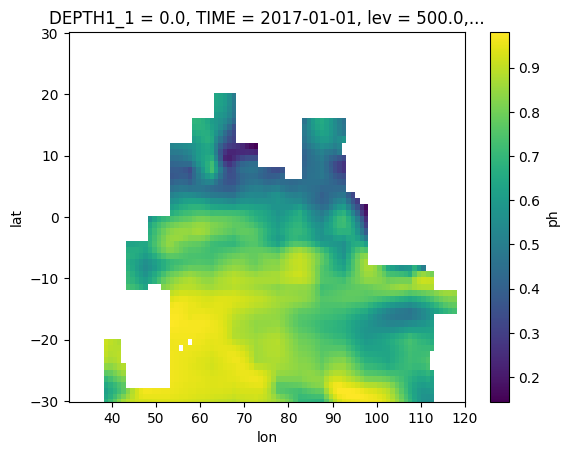

In [17]:
skill_cmems.ph.plot()

In [18]:
lat_range_as = slice(0, 30)
lon_range_as = slice(38, 78)

skill_bias_as = skill_cmems.sel(lat=lat_range_as, lon=lon_range_as).mean()
skill_bias_as.ph

<xarray.DataArray 'ph' ()> Size: 8B
array(0.51113399)
Coordinates:
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    lev       float64 8B 500.0
    olevel    float32 4B 0.5058

In [19]:
lat_range_bob = slice(0, 30)
lon_range_bob = slice(78, 120)

skill_bias_bob = skill_cmems.sel(lat=lat_range_bob, lon=lon_range_bob).mean()
skill_bias_bob.ph

<xarray.DataArray 'ph' ()> Size: 8B
array(0.48310668)
Coordinates:
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    lev       float64 8B 500.0
    olevel    float32 4B 0.5058

In [20]:
lat_range_cio = slice(-18, 0)
lon_range_cio = slice(30, 120)

skill_bias_cio = skill_cmems.sel(lat=lat_range_cio, lon=lon_range_cio).mean()
skill_bias_cio.ph

<xarray.DataArray 'ph' ()> Size: 8B
array(0.76298284)
Coordinates:
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    lev       float64 8B 500.0
    olevel    float32 4B 0.5058

In [21]:
lat_range_sio = slice(-30, -18)
lon_range_sio = slice(30, 120)

skill_bias_sio = skill_cmems.sel(lat=lat_range_sio, lon=lon_range_sio).mean()
skill_bias_sio.ph

<xarray.DataArray 'ph' ()> Size: 8B
array(0.83014343)
Coordinates:
    DEPTH1_1  float32 4B 0.0
    TIME      datetime64[ns] 8B 2017-01-01
    lev       float64 8B 500.0
    olevel    float32 4B 0.5058

In [182]:
#plot

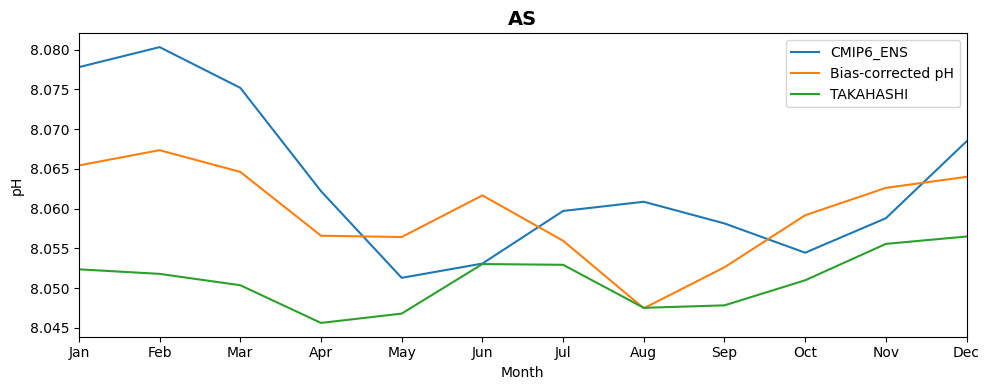

In [4]:
import matplotlib.pyplot as plt
import calendar

lat_range_as = slice(0, 30) 
lon_range_as = slice(38, 78)


subset_ds1 = cmems_sub.sel(lat=lat_range_as, lon=lon_range_as).mean(['lat', 'lon'])
subset_ds4 = bc_ens_sub.sel(lat=lat_range_as, lon=lon_range_as).mean(['lat', 'lon'])
subset_ds2 = ens_sub.sel(lat=lat_range_as, lon=lon_range_as).mean(['lat', 'lon'])
ds3_sub = tak.sel(lat=lat_range_as, lon=lon_range_as).mean(['lat', 'lon'])
subset_ds5 = soda_sub.sel(lat=lat_range_as, lon=lon_range_as).mean(['lat', 'lon'])
# subset_ds6 = subset_ds6.mean(['lat', 'lon'])
plt.figure(figsize=(10, 4))

# Plot all datasets
# subset_ds1.ph.plot(label='CMEMS')
subset_ds2.ph.plot(label='CMIP6_ENS', color='r')
# subset_ds4.ph.plot(label='Bias-corrected pH')
ds3_sub.ph.plot(label='TAKAHASHI')
# subset_ds5.ph.plot(label='SODA')


# Title
plt.title('AS', fontsize=14, fontweight='bold')

# X-axis as months Jan–Dec
months = range(1, 13)
month_labels = [calendar.month_abbr[m] for m in months]
plt.xticks(months, month_labels)
plt.xlim(1, 12)

# Labels and legend
plt.xlabel('Month')
plt.ylabel('pH')
plt.legend()

# plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('AS_monthly_pH_tak_r1.png', dpi=300, bbox_inches='tight')

plt.show()


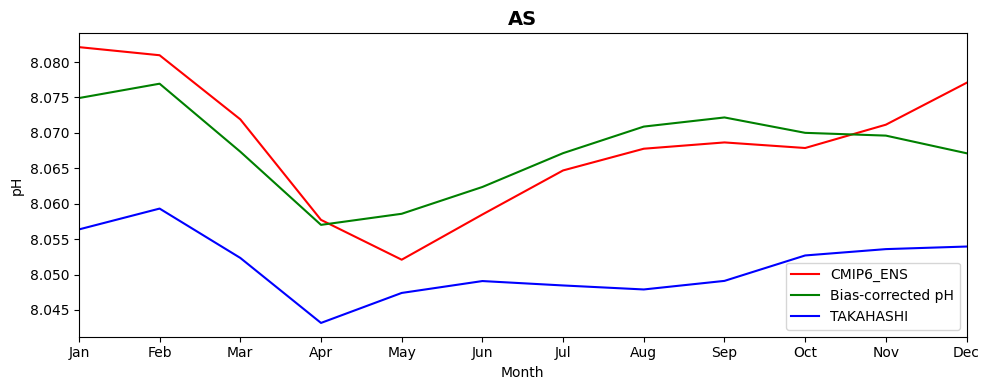

In [7]:
import matplotlib.pyplot as plt
import calendar

lat_range_as = slice(0, 30) 
lon_range_as = slice(78, 120)


subset_ds1 = cmems_sub.sel(lat=lat_range_as, lon=lon_range_as).mean(['lat', 'lon'])
subset_ds4 = bc_ens_sub.sel(lat=lat_range_as, lon=lon_range_as).mean(['lat', 'lon'])
subset_ds2 = ens_sub.sel(lat=lat_range_as, lon=lon_range_as).mean(['lat', 'lon'])
ds3_sub = tak.sel(lat=lat_range_as, lon=lon_range_as).mean(['lat', 'lon'])
subset_ds5 = soda_sub.sel(lat=lat_range_as, lon=lon_range_as).mean(['lat', 'lon'])
# subset_ds6 = subset_ds6.mean(['lat', 'lon'])
plt.figure(figsize=(10, 4))

# Plot all datasets
# subset_ds1.ph.plot(label='CMEMS')
subset_ds2.ph.plot(label='CMIP6_ENS', color='r')
subset_ds4.ph.plot(label='Bias-corrected pH', color='g')
ds3_sub.ph.plot(label='TAKAHASHI', color='b')
# subset_ds5.ph.plot(label='SODA')


# Title
plt.title('AS', fontsize=14, fontweight='bold')

# X-axis as months Jan–Dec
months = range(1, 13)
month_labels = [calendar.month_abbr[m] for m in months]
plt.xticks(months, month_labels)
plt.xlim(1, 12)

# Labels and legend
plt.xlabel('Month')
plt.ylabel('pH')
plt.legend()

# plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('bob_monthly_pH_tak_r1.png', dpi=300, bbox_inches='tight')

plt.show()


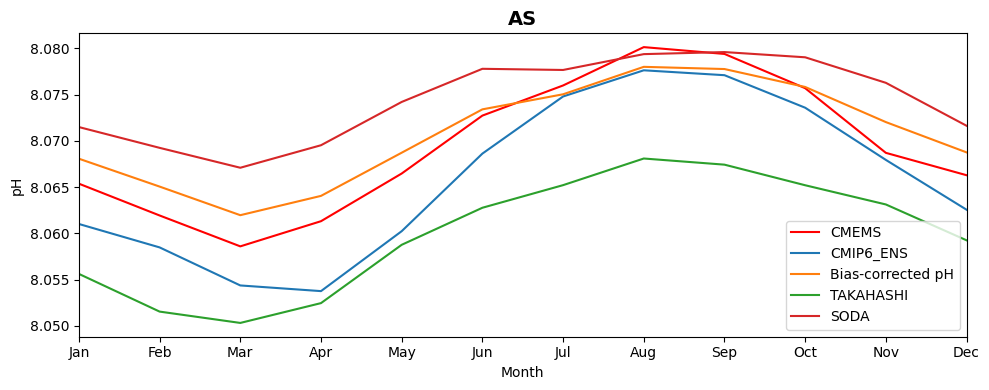

In [6]:
import matplotlib.pyplot as plt
import calendar

lat_range_as = slice(-18, 0) 
lon_range_as = slice(30, 120)


subset_ds1 = cmems_sub.sel(lat=lat_range_as, lon=lon_range_as).mean(['lat', 'lon'])
subset_ds4 = bc_ens_sub.sel(lat=lat_range_as, lon=lon_range_as).mean(['lat', 'lon'])
subset_ds2 = ens_sub.sel(lat=lat_range_as, lon=lon_range_as).mean(['lat', 'lon'])
ds3_sub = tak.sel(lat=lat_range_as, lon=lon_range_as).mean(['lat', 'lon'])
subset_ds5 = soda_sub.sel(lat=lat_range_as, lon=lon_range_as).mean(['lat', 'lon'])
# subset_ds6 = subset_ds6.mean(['lat', 'lon'])
plt.figure(figsize=(10, 4))

# Plot all datasets
subset_ds1.ph.plot(label='CMEMS', color='r')
subset_ds2.ph.plot(label='CMIP6_ENS')
subset_ds4.ph.plot(label='Bias-corrected pH')
ds3_sub.ph.plot(label='TAKAHASHI')
subset_ds5.ph.plot(label='SODA')


# Title
plt.title('AS', fontsize=14, fontweight='bold')

# X-axis as months Jan–Dec
months = range(1, 13)
month_labels = [calendar.month_abbr[m] for m in months]
plt.xticks(months, month_labels)
plt.xlim(1, 12)

# Labels and legend
plt.xlabel('Month')
plt.ylabel('pH')
plt.legend()

# plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('cio_monthly_pH_tak.png', dpi=300, bbox_inches='tight')

plt.show()


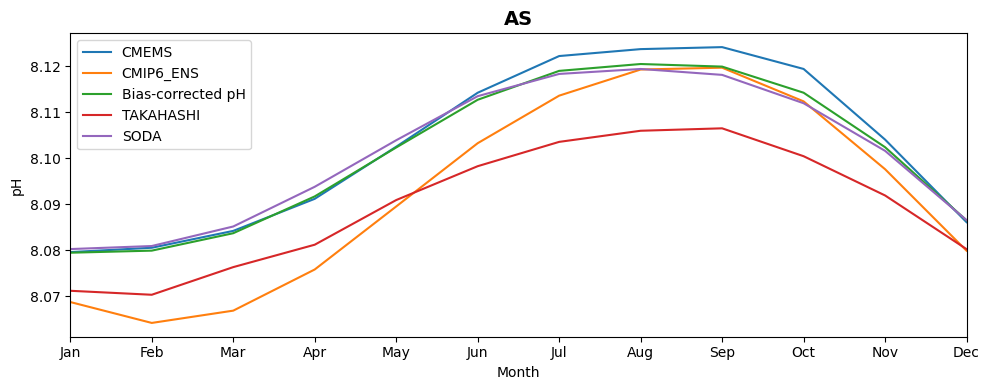

In [188]:
import matplotlib.pyplot as plt
import calendar

lat_range_as = slice(-30, -18) 
lon_range_as = slice(30, 120)


subset_ds1 = cmems_sub.sel(lat=lat_range_as, lon=lon_range_as).mean(['lat', 'lon'])
subset_ds4 = bc_ens_sub.sel(lat=lat_range_as, lon=lon_range_as).mean(['lat', 'lon'])
subset_ds2 = ens_sub.sel(lat=lat_range_as, lon=lon_range_as).mean(['lat', 'lon'])
ds3_sub = tak.sel(lat=lat_range_as, lon=lon_range_as).mean(['lat', 'lon'])
subset_ds5 = soda_sub.sel(lat=lat_range_as, lon=lon_range_as).mean(['lat', 'lon'])
# subset_ds6 = subset_ds6.mean(['lat', 'lon'])
plt.figure(figsize=(10, 4))

# Plot all datasets
subset_ds1.ph.plot(label='CMEMS')
subset_ds2.ph.plot(label='CMIP6_ENS')
subset_ds4.ph.plot(label='Bias-corrected pH')
ds3_sub.ph.plot(label='TAKAHASHI')
subset_ds5.ph.plot(label='SODA')


# Title
plt.title('AS', fontsize=14, fontweight='bold')

# X-axis as months Jan–Dec
months = range(1, 13)
month_labels = [calendar.month_abbr[m] for m in months]
plt.xticks(months, month_labels)
plt.xlim(1, 12)

# Labels and legend
plt.xlabel('Month')
plt.ylabel('pH')
plt.legend()

# plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('sio_monthly_pH_tak.png', dpi=300, bbox_inches='tight')

plt.show()
